In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.cm import ScalarMappable

In [2]:
tcga_path = 'data/tcga_mut_somaticgermline.tsv'
roles_path = 'data/generoles.tsv'
pancan_path = 'data/pancan_twohitfreq.tsv'
tumor_path = 'data/tumor_twohitfreq.tsv'
tmb_path = "data/mutation-load_updated.txt"
fga_path = "data/seg_based_scores.tsv"

In [3]:
tcga = pd.read_csv(tcga_path, sep = '\t')
roles = pd.read_csv(roles_path, sep = '\t')
pancan = pd.read_csv(pancan_path, sep = '\t')
tumor = pd.read_csv(tumor_path, sep = '\t')
tmb = pd.read_csv(tmb_path, sep = '\t')
fga = pd.read_csv(fga_path, sep = '\t')

/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (12) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
def config_rcparams():
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = ['arial']
    plt.rcParams['svg.fonttype'] = 'none' 
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.cal'] = 'arial'
    plt.rcParams['mathtext.rm'] = 'arial'
    plt.rcParams['axes.linewidth'] = 0.7
    plt.rcParams['xtick.major.width'] = 0.7
    plt.rcParams['ytick.major.width'] = 0.7
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3

---

# Fig S2

Preparing dataset

In [5]:
# calculating pancancer 2 hit frequencies

tcgaf = tcga[(tcga.Variant_Classification!='Silent')&(tcga.midan_filter=='keep')]

pancan2hitfreqs = tcgaf.groupby(['Hugo_Symbol','zygosity']).tissue.nunique().to_frame().rename(columns={'tissue':'counts'}).reset_index().pivot(index='Hugo_Symbol',columns='zygosity',values='counts').fillna(0).reset_index()
pancan2hitfreqs['tot'] = pancan2hitfreqs['1-hit']+pancan2hitfreqs['2-hit']
print(len(pancan2hitfreqs))
pancan2hitfreqs = pancan2hitfreqs[pancan2hitfreqs.tot>=5]
print(len(pancan2hitfreqs))
pancan2hitfreqs['2hitfreq'] = pancan2hitfreqs['2-hit']/pancan2hitfreqs['tot']

print(len(pancan2hitfreqs))
pancan2hitfreqs = pd.merge(pancan2hitfreqs,roles, on='Hugo_Symbol', how='left')
print(len(pancan2hitfreqs))

pancan2hitfreqs_tsgs = pancan2hitfreqs[pancan2hitfreqs.role=='TSG'].copy()

19209
17514
17514
17514


In [6]:
# calculating tumor specific 2 hit frequencies

tumor2hitfreqs = tcgaf.groupby(['Hugo_Symbol','CODE','zygosity']).tissue.nunique().to_frame().rename(columns={'tissue':'counts'}).reset_index().pivot(index=['Hugo_Symbol','CODE'],columns='zygosity',values='counts').fillna(0).reset_index()
tumor2hitfreqs['tot'] = tumor2hitfreqs['1-hit']+tumor2hitfreqs['2-hit']
print(len(tumor2hitfreqs))
tumor2hitfreqs = tumor2hitfreqs[tumor2hitfreqs.tot>=5]
print(len(tumor2hitfreqs))
tumor2hitfreqs['2hitfreq'] = tumor2hitfreqs['2-hit']/tumor2hitfreqs['tot']

print(len(tumor2hitfreqs))
tumor2hitfreqs = pd.merge(tumor2hitfreqs,roles, on='Hugo_Symbol', how='left')
print(len(tumor2hitfreqs))

tumor2hitfreqs_tsgs = tumor2hitfreqs[tumor2hitfreqs.role=='TSG'].copy()

211688
26886
26886
26886


In [7]:
# comparing pancan vs tumor specific 2hitfreq of tsgs

tmp1 = tumor2hitfreqs[tumor2hitfreqs.role=='TSG'].pivot(index='Hugo_Symbol',columns='CODE',values='2hitfreq').dropna(axis='rows',how='all').dropna(axis='columns',how='all')
tmp2 = pancan2hitfreqs[pancan2hitfreqs.role=='TSG'][['Hugo_Symbol','2hitfreq']].set_index('Hugo_Symbol').rename({'2hitfreq':'Pancan'},axis='columns')
tsg2hitfreqs = tmp2.join(tmp1).reset_index()

print(tsg2hitfreqs.shape)

(132, 33)


In [8]:
# adding tumor types with no computable 2hit freqs in TSGs 

print(np.setdiff1d(tcgaf.CODE.unique(),tsg2hitfreqs.columns.values))

tsg2hitfreqs['TGCT']=np.nan
tsg2hitfreqs['THYM']=np.nan

tmp = tsg2hitfreqs.set_index(['Hugo_Symbol','Pancan']).copy()
tsg2hitfreqs = tmp[sorted(tmp.columns)].reset_index()

['TGCT' 'THYM']


In [9]:
# preparing dataset

tmp1 = tumor2hitfreqs[tumor2hitfreqs.role=='TSG'][['Hugo_Symbol','CODE','tot']]
tmp2 = pancan2hitfreqs[pancan2hitfreqs.role=='TSG'][['Hugo_Symbol','tot']]
tmp2['CODE'] = 'Pancan'
tots = pd.concat([tmp1,tmp2])

tsg2hitfreqs_melt = tsg2hitfreqs.melt(id_vars='Hugo_Symbol',value_vars=(['Pancan']+list(tcgaf.CODE.unique())))
tsg2hitfreqs_melt.columns = ['Hugo_Symbol','CODE','2hitfreq']
print(len(tsg2hitfreqs_melt))
tsg2hitfreqs_melt = pd.merge(tsg2hitfreqs_melt,tots,on=['Hugo_Symbol','CODE'],how='left')
print(len(tsg2hitfreqs_melt))

4488
4488


Cancer type plot

In [10]:
# preparing dataset and color palettes

data = tsg2hitfreqs_melt[tsg2hitfreqs_melt.CODE!='Pancan'].copy()
data['gene_tumor'] = data['Hugo_Symbol']+'_'+data['CODE']
data = pd.merge(data,tumor[['gene_tumor','pval','FDR']],how='left')
data['2hitfreq'] = pd.to_numeric(data['2hitfreq'], errors='coerce')

# Color palette normalisation
cmap = sns.color_palette("coolwarm", as_cmap=True)

norm = mcolors.TwoSlopeNorm(
    vmin=data['2hitfreq'].min(),
    vcenter=0.3,
    vmax=data['2hitfreq'].max()
)

def custom_size_scaler(n):
    if n <= 20:
        return 100 + (n - 5) / (20 - 5) * (150 - 100)
    elif n <= 50:
        return 150 + (n - 21) / (50 - 21) * (220 - 150)
    elif n <= 150:
        return 220 + (n - 51) / (150 - 51) * (310 - 220)
    elif n <= 350:
        return 310 + (n - 151) / (350 - 151) * (420 - 310)
    elif n <= 500:
        return 420 + (n - 151) / (350 - 151) * (540 - 420)
    else:
        return 540 + (n - 351) / (3000 - 351) * (680 - 540)

data['bubble_size'] = data['tot'].apply(custom_size_scaler)
data['outline_color'] = 'white'
data['outline_color'] = data['outline_color'].mask(data['pval']<0.05,'grey')
data['outline_color'] = data['outline_color'].mask(data['FDR']<0.05,'black')
data['bubble_color'] = data['2hitfreq'].apply(lambda val: cmap(norm(val)))

In [11]:
# Defining gene groups

tsgs = pancan['Hugo_Symbol'].unique()
pfdr = pancan[pancan['FDR']<0.05]['Hugo_Symbol'].unique()
tfdr = tumor[tumor['FDR']<0.05]['Hugo_Symbol'].unique()

pt = np.intersect1d(pfdr,tfdr)
p = np.setdiff1d(pfdr,tfdr)
t = np.setdiff1d(tfdr,pfdr)
n = np.setdiff1d(np.setdiff1d(tsgs,pfdr),tfdr)

len(pt)+len(p)+len(t)+len(n)==len(tsgs)

True

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


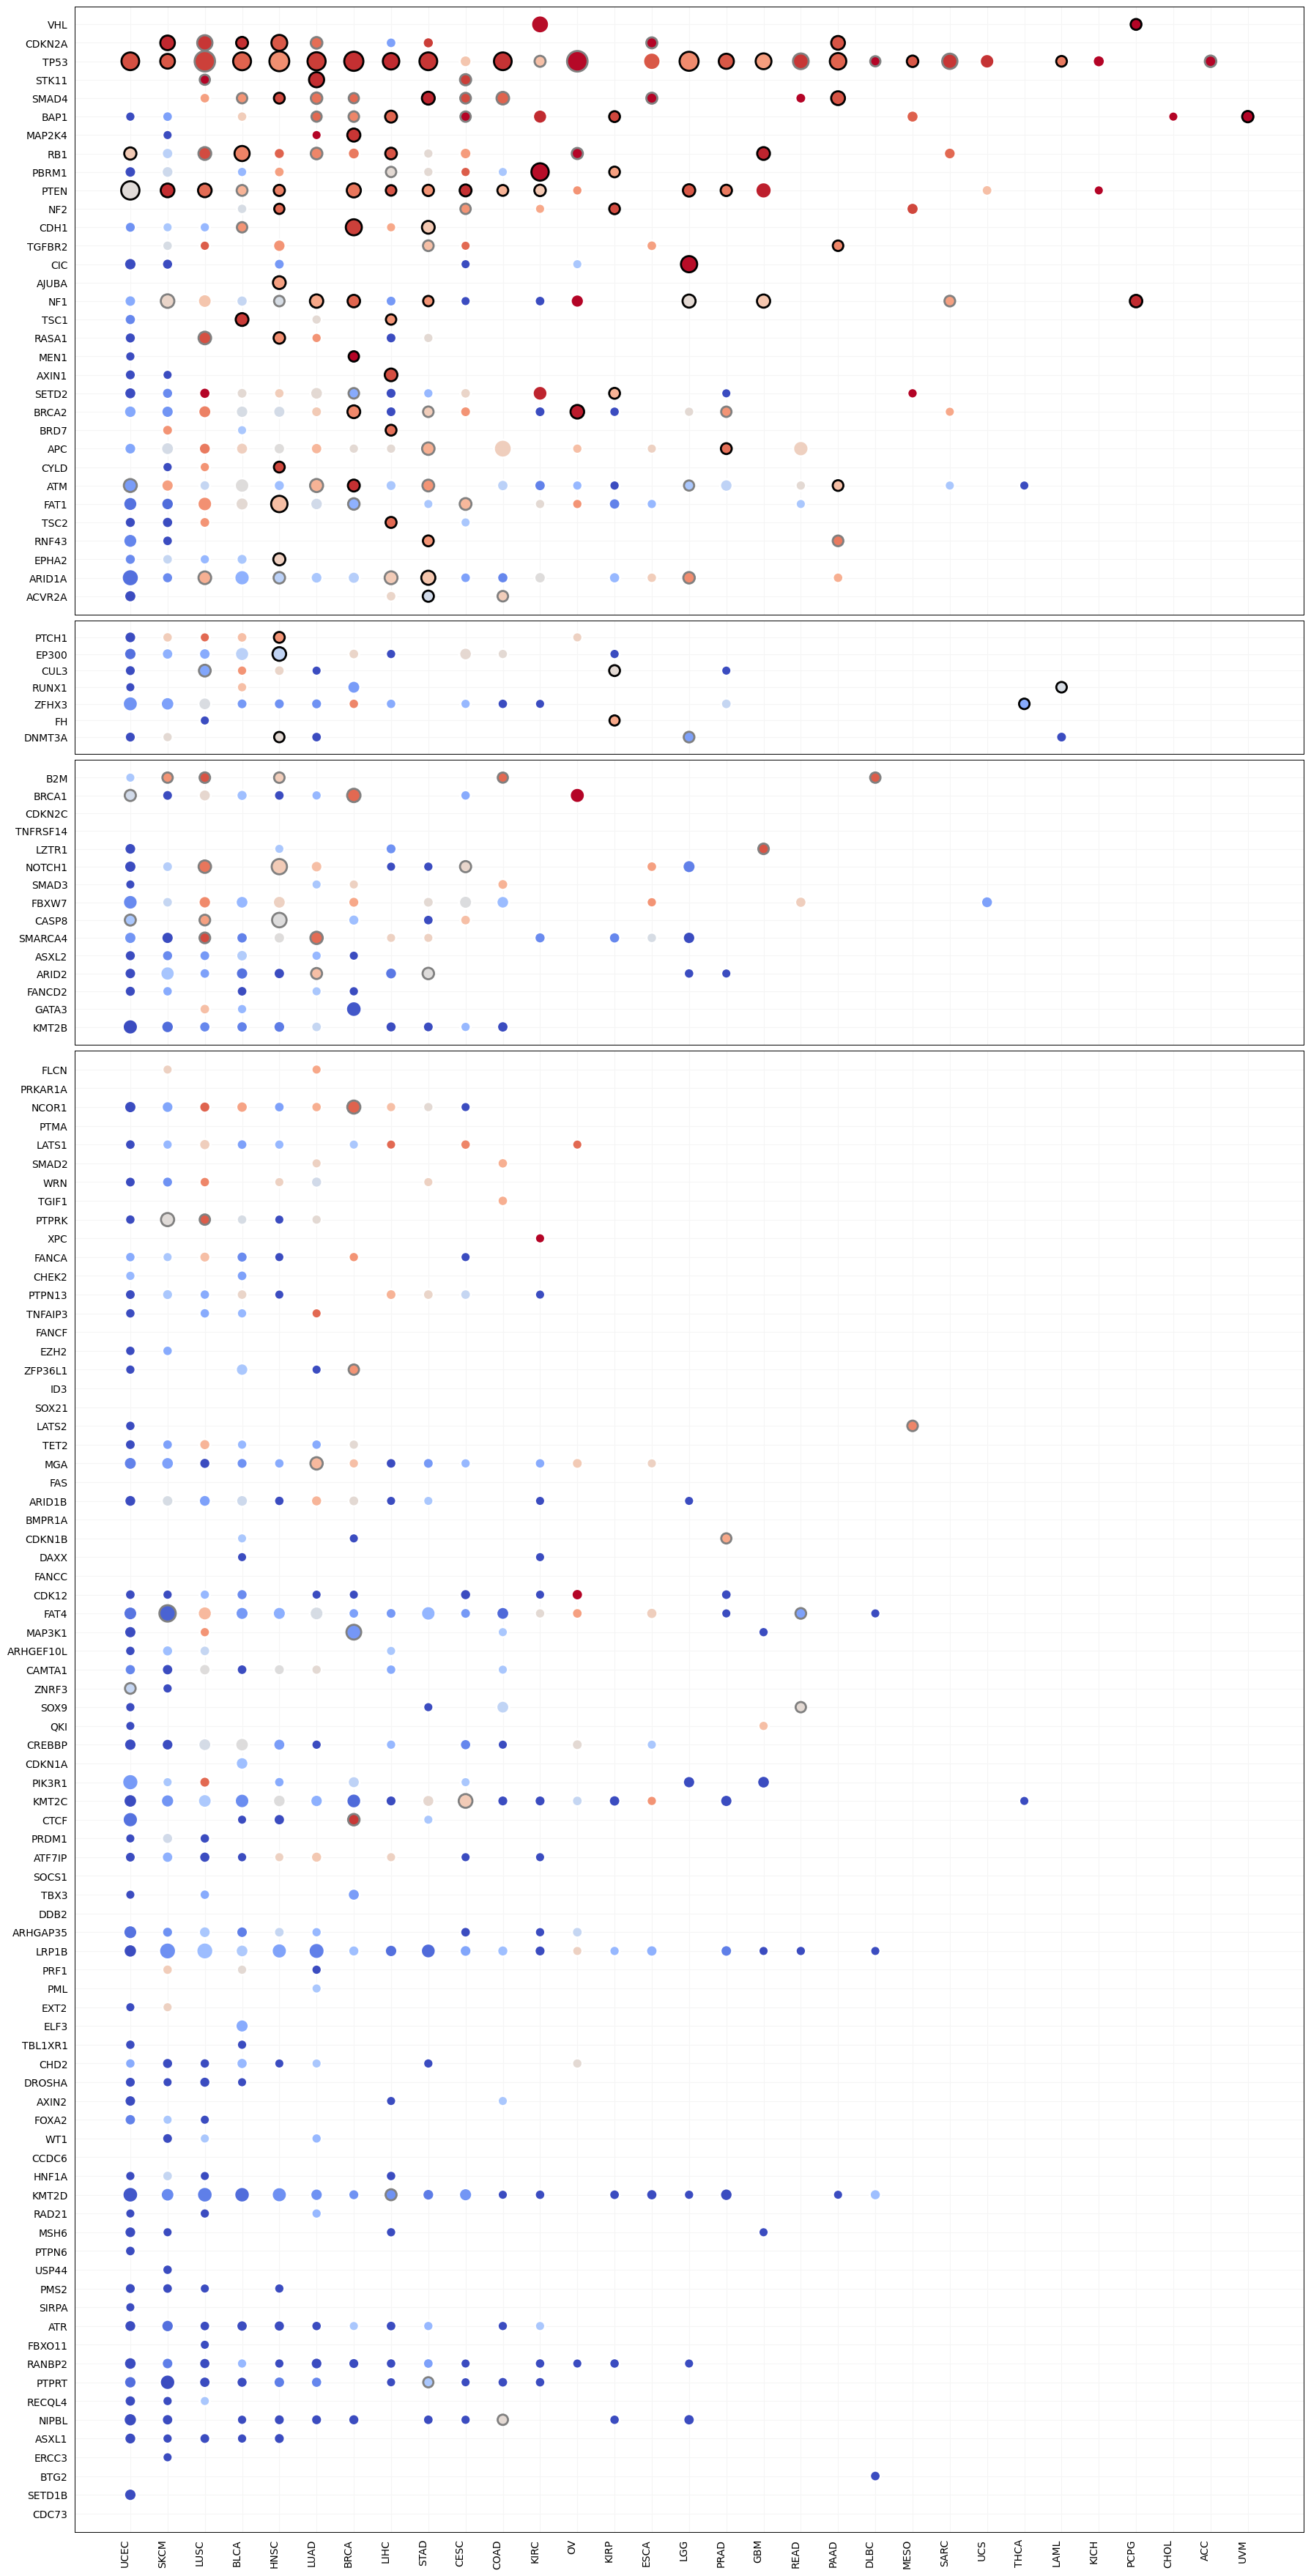

In [12]:
config_rcparams()

# Tumor type plot

fig, axs = plt.subplots(4, 1, figsize=(18, 35), sharex=True, 
                        gridspec_kw={'height_ratios': [30*len(pt)/len(tsgs), 30*len(t)/len(tsgs), 30*len(p)/len(tsgs), 30*len(n)/len(tsgs)]})  
ax1, ax2, ax3, ax4 = axs

# FDR<0.05 pancancer and in at least 1 tumor type

df = data[data.Hugo_Symbol.isin(pt)].copy()
custom_code_order = list(data.dropna().CODE.value_counts().index)

custom_gene_order1 = list(pancan[pancan.Hugo_Symbol.isin(pt)].sort_values(by='2hitfreq')['Hugo_Symbol'].values)
subdfs=[]
for gene in custom_gene_order1:
    for code in custom_code_order:
        subdfs.append(df[(df.Hugo_Symbol==gene)&(df.CODE==code)])
df_mod=pd.concat(subdfs)

df_valid = df_mod

ax1.scatter(
    y=df_valid['Hugo_Symbol'],
    x=df_valid['CODE'],
    s=df_valid['bubble_size'],
    c=df_valid['bubble_color'],
    edgecolors=df_valid['outline_color'],
    linewidths=2
)

# FDR<0.05 pancancer only

df = data[data.Hugo_Symbol.isin(t)].copy()

custom_gene_order2 = list(pancan[pancan.Hugo_Symbol.isin(t)].sort_values(by='2hitfreq')['Hugo_Symbol'].values)
subdfs=[]
for gene in custom_gene_order2:
    for code in custom_code_order:
        subdfs.append(df[(df.Hugo_Symbol==gene)&(df.CODE==code)])
df_mod=pd.concat(subdfs)

df_valid = df_mod

ax2.scatter(
    y=df_valid['Hugo_Symbol'],
    x=df_valid['CODE'],
    s=df_valid['bubble_size'],
    c=df_valid['bubble_color'],
    edgecolors=df_valid['outline_color'],
    linewidths=2
)


# FDR<0.05 in tumor type only

df = data[data.Hugo_Symbol.isin(p)].copy()

custom_gene_order3 = list(pancan[pancan.Hugo_Symbol.isin(p)].sort_values(by='2hitfreq')['Hugo_Symbol'].values)
subdfs=[]
for gene in custom_gene_order3:
    for code in custom_code_order:
        subdfs.append(df[(df.Hugo_Symbol==gene)&(df.CODE==code)])
df_mod=pd.concat(subdfs)

df_valid = df_mod

ax3.scatter(
    y=df_valid['Hugo_Symbol'],
    x=df_valid['CODE'],
    s=df_valid['bubble_size'],
    c=df_valid['bubble_color'],
    edgecolors=df_valid['outline_color'],
    linewidths=2
)


# FDR>=0.05

df = data[data.Hugo_Symbol.isin(n)].copy()

custom_gene_order4 = list(pancan[pancan.Hugo_Symbol.isin(n)].sort_values(by='2hitfreq')['Hugo_Symbol'].values)
subdfs=[]
for gene in custom_gene_order4:
    for code in custom_code_order:
        subdfs.append(df[(df.Hugo_Symbol==gene)&(df.CODE==code)])
df_mod=pd.concat(subdfs)

df_valid = df_mod

ax4.scatter(
    y=df_valid['Hugo_Symbol'],
    x=df_valid['CODE'],
    s=df_valid['bubble_size'],
    c=df_valid['bubble_color'],
    edgecolors=df_valid['outline_color'],
    linewidths=2
)


ax1.set_ylim(-1, len(custom_gene_order1) - 0.05)
ax2.set_ylim(-1, len(custom_gene_order2) )
ax3.set_ylim(-1, len(custom_gene_order3))
ax4.set_ylim(-1, len(custom_gene_order4))

ax1.grid(True,color='whitesmoke')
ax2.grid(True,color='whitesmoke')
ax3.grid(True,color='whitesmoke')
ax4.grid(True,color='whitesmoke')
ax1.set_axisbelow(True) 
ax2.set_axisbelow(True) 
ax3.set_axisbelow(True) 
ax4.set_axisbelow(True)

plt.tight_layout(h_pad=0.3)
plt.xticks(rotation=90, ha='right')

ax1.tick_params(axis='y', left=False)
ax1.tick_params(axis='x', bottom=False)
ax2.tick_params(axis='y', left=False)
ax2.tick_params(axis='x', bottom=False)
ax3.tick_params(axis='y', left=False)
ax3.tick_params(axis='x', bottom=False)
ax4.tick_params(axis='y', left=False)
ax4.tick_params(axis='x', bottom=False)

plt.show()

Pan-cancer plot

In [13]:
# preparing data_pancanset and color palettes

data_pancan = pancan.copy()
data_pancan['CODE'] = 'Pancancer'
data_pancan['2hitfreq'] = pd.to_numeric(data_pancan['2hitfreq'], errors='coerce')

# custom_size_scaler(n) already defined

data_pancan['bubble_size'] = data_pancan['tot'].apply(custom_size_scaler)
data_pancan['outline_color'] = 'white'
data_pancan['outline_color'] = data_pancan['outline_color'].mask(data_pancan['pval']<0.05,'grey')
data_pancan['outline_color'] = data_pancan['outline_color'].mask(data_pancan['FDR']<0.05,'black')
data_pancan['bubble_color'] = data_pancan['2hitfreq'].apply(lambda val: cmap(norm(val)))

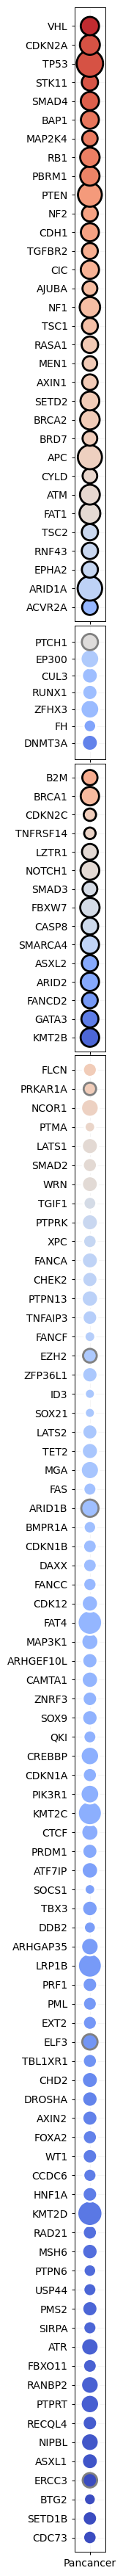

In [14]:
# pancan plot

config_rcparams()
fig, axs = plt.subplots(4, 1, figsize=(18/33, 45), sharex=True, 
                        gridspec_kw={'height_ratios': [30*len(pt)/len(tsgs), 30*len(t)/len(tsgs), 30*len(p)/len(tsgs), 30*len(n)/len(tsgs)]})  
ax1, ax2, ax3, ax4 = axs

# FDR<0.05 pancancer and in at least 1 tumor type

df = data_pancan[data_pancan.Hugo_Symbol.isin(pt)].copy()

custom_gene_order1 = list(pancan[pancan.Hugo_Symbol.isin(pt)].sort_values(by='2hitfreq')['Hugo_Symbol'].values)
subdfs=[]
for gene in custom_gene_order1:
    subdfs.append(df[df.Hugo_Symbol==gene])
df_mod=pd.concat(subdfs)

df_valid = df_mod.dropna(subset=['bubble_size'])

ax1.scatter(
    y=df_valid['Hugo_Symbol'],
    x=df_valid['CODE'],
    s=df_valid['bubble_size'],
    c=df_valid['bubble_color'],
    edgecolors=df_valid['outline_color'],
    linewidths=2
)


# FDR<0.05 pancancer only

df = data_pancan[data_pancan.Hugo_Symbol.isin(t)].copy()

custom_gene_order2 = list(pancan[pancan.Hugo_Symbol.isin(t)].sort_values(by='2hitfreq')['Hugo_Symbol'].values)
subdfs=[]
for gene in custom_gene_order2:
    subdfs.append(df[df.Hugo_Symbol==gene])
df_mod=pd.concat(subdfs)

df_valid = df_mod.dropna(subset=['bubble_size'])

ax2.scatter(
    y=df_valid['Hugo_Symbol'],
    x=df_valid['CODE'],
    s=df_valid['bubble_size'],
    c=df_valid['bubble_color'],
    edgecolors=df_valid['outline_color'],
    linewidths=2
)


# FDR<0.05 in tumor type only

df = data_pancan[data_pancan.Hugo_Symbol.isin(p)].copy()

custom_gene_order3 = list(pancan[pancan.Hugo_Symbol.isin(p)].sort_values(by='2hitfreq')['Hugo_Symbol'].values)
subdfs=[]
for gene in custom_gene_order3:
    subdfs.append(df[df.Hugo_Symbol==gene])
df_mod=pd.concat(subdfs)

df_valid = df_mod.dropna(subset=['bubble_size'])

ax3.scatter(
    y=df_valid['Hugo_Symbol'],
    x=df_valid['CODE'],
    s=df_valid['bubble_size'],
    c=df_valid['bubble_color'],
    edgecolors=df_valid['outline_color'],
    linewidths=2
)


# FDR>=0.05

df = data_pancan[data_pancan.Hugo_Symbol.isin(n)].copy()

custom_gene_order4 = list(pancan[pancan.Hugo_Symbol.isin(n)].sort_values(by='2hitfreq')['Hugo_Symbol'].values)
subdfs=[]
for gene in custom_gene_order4:
    subdfs.append(df[df.Hugo_Symbol==gene])
df_mod=pd.concat(subdfs)

df_valid = df_mod.dropna(subset=['bubble_size'])

ax4.scatter(
    y=df_valid['Hugo_Symbol'],
    x=df_valid['CODE'],
    s=df_valid['bubble_size'],
    c=df_valid['bubble_color'],
    edgecolors=df_valid['outline_color'],
    linewidths=2
)


ax1.set_ylim(-0.75, len(custom_gene_order1))
ax2.set_ylim(-1, len(custom_gene_order2))
ax3.set_ylim(-0.75, len(custom_gene_order3)-0.25)
ax4.set_ylim(-0.75, len(custom_gene_order4)-0.25)
ax1.set_axisbelow(True) 
ax2.set_axisbelow(True) 
ax3.set_axisbelow(True) 
ax4.set_axisbelow(True)

ax1.grid(True,color='whitesmoke')
ax2.grid(True,color='whitesmoke')
ax3.grid(True,color='whitesmoke')
ax4.grid(True,color='whitesmoke')

plt.subplots_adjust(hspace=0.0065)

plt.show()

Bar plot

In [15]:
# along TSGs

# preparing dataframe

tested = data[['Hugo_Symbol','CODE','2hitfreq']].dropna().groupby(['Hugo_Symbol'])['CODE'].nunique().to_frame().rename(columns={'CODE':'tested'})
sig = data[data['FDR']<0.05][['Hugo_Symbol','CODE','2hitfreq']].dropna().groupby(['Hugo_Symbol'])['CODE'].nunique().to_frame().rename(columns={'CODE':'sig'})
tmp = tested.join(sig).fillna(0)
tmp['sig/tested'] = tmp['sig']/tmp['tested']

add = pd.DataFrame(index=np.setdiff1d(tsgs,tmp.index))
add['tested']=np.nan
add['sig']=np.nan
add['sig/tested']=np.nan

tmp = pd.concat([tmp,add])
tmp = tmp.reset_index().rename(columns={'index':'Hugo_Symbol'})
tmp['nonsig'] = tmp['tested'] - tmp['sig']

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


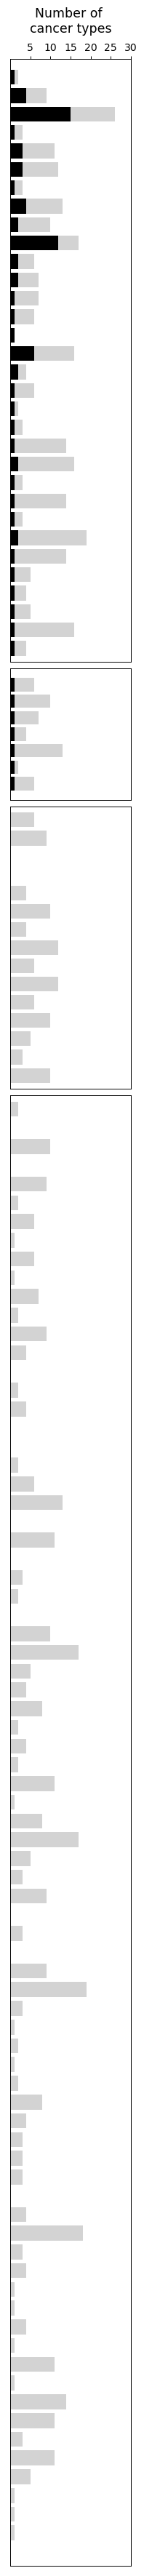

In [16]:
# along TSGs

# plot

config_rcparams()

fig, axs = plt.subplots(4, 1, figsize=(2, 35), sharex=True, 
                        gridspec_kw={'height_ratios': [30*len(pt)/len(tsgs), 30*len(t)/len(tsgs), 30*len(p)/len(tsgs), 30*len(n)/len(tsgs)]})  
ax1, ax2, ax3, ax4 = axs

# FDR<0.05 pancancer and in at least 1 tumor type

df = tmp[tmp.Hugo_Symbol.isin(pt)].copy()

custom_gene_order1 = list(pancan[pancan.Hugo_Symbol.isin(pt)].sort_values(by='2hitfreq')['Hugo_Symbol'].values)
subdfs=[]
for gene in custom_gene_order1:
    subdfs.append(df[df.Hugo_Symbol==gene])
df_mod=pd.concat(subdfs)

df_valid = df_mod

ax1.barh(df_valid['Hugo_Symbol'], df_valid['sig'], label='FDR<0.05', color='black')
ax1.barh(df_valid['Hugo_Symbol'], df_valid['nonsig'], left=df_valid['sig'], label='Tested', color='lightgray')


# FDR<0.05 pancancer only

df = tmp[tmp.Hugo_Symbol.isin(t)].copy()

custom_gene_order2 = list(pancan[pancan.Hugo_Symbol.isin(t)].sort_values(by='2hitfreq')['Hugo_Symbol'].values)
subdfs=[]
for gene in custom_gene_order2:
    subdfs.append(df[df.Hugo_Symbol==gene])
df_mod=pd.concat(subdfs)

df_valid = df_mod

ax2.barh(df_valid['Hugo_Symbol'], df_valid['sig'], label='FDR<0.05', color='black')
ax2.barh(df_valid['Hugo_Symbol'], df_valid['nonsig'], left=df_valid['sig'], label='Tested', color='lightgray')

# FDR<0.05 in tumor type only

df = tmp[tmp.Hugo_Symbol.isin(p)].copy()

custom_gene_order3 = list(pancan[pancan.Hugo_Symbol.isin(p)].sort_values(by='2hitfreq')['Hugo_Symbol'].values)
subdfs=[]
for gene in custom_gene_order3:
    subdfs.append(df[df.Hugo_Symbol==gene])
df_mod=pd.concat(subdfs)

df_valid = df_mod

ax3.barh(df_valid['Hugo_Symbol'], df_valid['nonsig'], label='FDR<0.05', color='lightgray')

# FDR>=0.05

df = tmp[tmp.Hugo_Symbol.isin(n)].copy()

custom_gene_order4 = list(pancan[pancan.Hugo_Symbol.isin(n)].sort_values(by='2hitfreq')['Hugo_Symbol'].values)
subdfs=[]
for gene in custom_gene_order4:
    subdfs.append(df[df.Hugo_Symbol==gene])
df_mod=pd.concat(subdfs)

df_valid = df_mod

ax4.barh(df_valid['Hugo_Symbol'], df_valid['nonsig'], label='FDR<0.05', color='lightgray')

ax1.set_ylim(-0.75, len(custom_gene_order1))
ax2.set_ylim(-1, len(custom_gene_order2))
ax3.set_ylim(-0.75, len(custom_gene_order3)-0.25)
ax4.set_ylim(-0.75, len(custom_gene_order4)-0.25)

ax1.yaxis.set_visible(False)
ax2.yaxis.set_visible(False)
ax3.yaxis.set_visible(False)
ax4.yaxis.set_visible(False)

plt.tight_layout(h_pad=0.3)

xtick_positions = [5, 10, 15, 20, 25, 30]
xtick_labels = ['5', '10', '15', '20', '25', '30']
plt.xticks(ticks=xtick_positions, labels=xtick_labels, rotation=90, ha='right', fontsize=12.5)
ax1.tick_params(labeltop=True, labelbottom=False)
ax1.xaxis.tick_top()
#ax1.xaxis.set_visible(False)
ax2.xaxis.set_visible(False)
ax3.xaxis.set_visible(False)
ax4.xaxis.set_visible(False)

ax1.set_xlabel("Number of \ncancer types", labelpad=10, fontsize=12.5)
ax1.xaxis.set_label_position('top')

plt.show()

In [17]:
# along CODEs

# preparing dataframe

tested = data[['Hugo_Symbol','CODE','2hitfreq']].dropna().groupby(['CODE'])['Hugo_Symbol'].nunique().to_frame().rename(columns={'Hugo_Symbol':'tested'})
sig = data[data['FDR']<0.05][['Hugo_Symbol','CODE','2hitfreq']].dropna().groupby(['CODE'])['Hugo_Symbol'].nunique().to_frame().rename(columns={'Hugo_Symbol':'sig'})
tmp = tested.join(sig).fillna(0)
tmp['sig/tested'] = tmp['sig']/tmp['tested']

add = pd.DataFrame(index=np.setdiff1d(tcga.CODE.unique(),tmp.index))
add['tested']=np.nan
add['sig']=np.nan
add['sig/tested']=np.nan

tmp = pd.concat([tmp,add])
tmp = tmp.reset_index().rename(columns={'index':'CODE'})
tmp['nonsig'] = tmp['tested'] - tmp['sig']

dfs = []

for code in custom_code_order:
    dfs.append(tmp[tmp.CODE==code])

df = pd.concat(dfs)

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'sans-serif' not found because none of the following families were found: arial


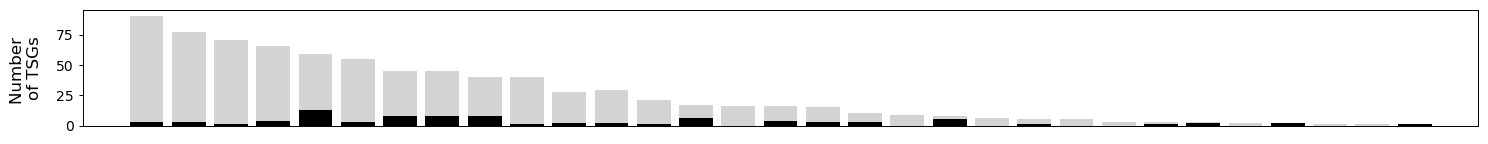

In [18]:
config_rcparams()

# along CODEs

# plot

fig, ax = plt.subplots(figsize=(18,1.5))

ax.bar(df['CODE'], df['sig'], label='FDR<0.05', color='black')
ax.bar(df['CODE'], df['nonsig'], bottom=df['sig'], label='Tested', color='lightgray')

ax.xaxis.set_visible(False)
plt.xticks(rotation=90, ha='right')
plt.xlim(-1.5,31.5)
plt.ylabel('Number \nof TSGs', labelpad=10, fontsize=12)

plt.show()

----

# Fig S1B

SignificanceResult(statistic=-0.4049283962973242, pvalue=0.023841788899670074)


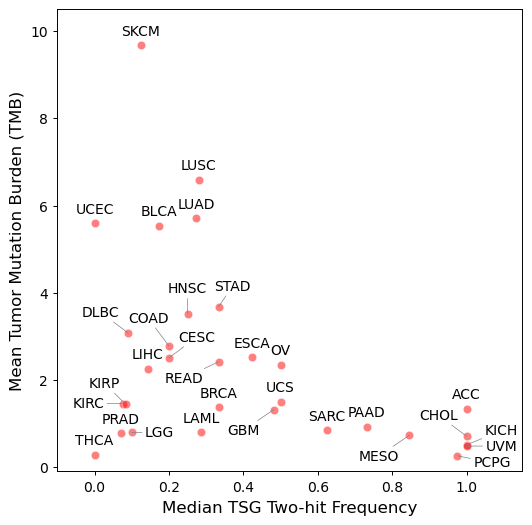

In [19]:
config_rcparams()

plt.figure(figsize=(6,6))

codes_to_annotate = {
    "COAD": (-15, 10),
    "HNSC": (0, 8),
    "GBM": (-22, -25),
    "CESC": (20, 5),
    "KIRC": (-15, -10),
    "LGG": (20, -10),
    "UVM": (25, -10),
    "CHOL": (-20, 5),
    "KICH": (25, 0),
    "PCPG": (25, -15),
    "READ": (-25, -22),
    "STAD": (10, 5),
    "DLBC": (-20, 5),
    "KIRC": (-25, -10),
    "KIRP": (-15, 5),
    "MESO": (-22, -25)
}

x = tumor2hitfreqs[tumor2hitfreqs.role=='TSG'].groupby('CODE')['2hitfreq'].median().to_frame()
tmb_mod = tmb[tmb.Patient_ID.isin(tcgaf.tissue.unique())]
y = tmb_mod[tmb_mod.Patient_ID.isin(tcgaf.tissue.unique())].groupby('Cohort')['Non-silent per Mb'].mean().to_frame()
data = x.join(y).reset_index()

ax = sns.scatterplot(data=data, x='2hitfreq', y='Non-silent per Mb', color='red', alpha=0.5)

sel=data
for _, row in sel.iterrows():
    x, y = row['2hitfreq'], row['Non-silent per Mb']
    label = row['CODE']
    dx, dy = (0, 5)  
    
    if label in codes_to_annotate:
        extra_dx, extra_dy = codes_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=10,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=10,
            ha="center", va="bottom",          
        )

    
#ax.plot([-10, 110], [-10, 110],color='k',linestyle=':')

plt.xlim(-0.1,1.15)
plt.ylim(-0.1,10.5)
plt.xlabel('Median TSG Two-hit Frequency', fontsize=12)
plt.ylabel('Mean Tumor Mutation Burden (TMB)', fontsize=12)

print(stats.spearmanr(data['Non-silent per Mb'].values,data['2hitfreq'].values, nan_policy='omit'))

plt.show()

---

# Fig S1C

SignificanceResult(statistic=0.45824565147063767, pvalue=0.0095282206313718)


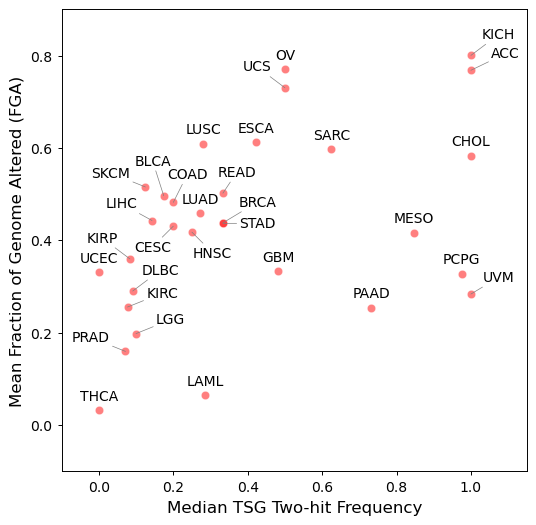

In [20]:
config_rcparams()

plt.figure(figsize=(6,6))

codes_to_annotate = {
    "SKCM": (-25, 0),
    "LIHC": (-22, 2),
    "UVM": (20, 2),
    "CESC": (-15,-25),
    "HNSC": (15,-25),
    "PRAD": (-25, 0),
    "UCS": (-20, 5),
    "ACC": (25, 2),
    "KICH": (20, 5),
    "STAD": (25, -10),
    "READ": (10, 5),
    "COAD": (10, 10),
    "BRCA": (25, 5),
    "KIRC": (25, 0),
    "KIRP": (-20, 5),
    "DLBC": (20, 5),
    "BLCA": (-8, 15),
    "LGG": (25, 0),
}

x = tumor2hitfreqs[tumor2hitfreqs.role=='TSG'].groupby('CODE')['2hitfreq'].median().to_frame()
fga_mod = pd.merge(tcga[['Sample','CODE']].drop_duplicates(),fga,on='Sample')
y = fga_mod.groupby('CODE')['frac_altered'].mean().to_frame()
data = x.join(y).reset_index()

ax = sns.scatterplot(data=data, x='2hitfreq', y='frac_altered', color='red', alpha=0.5)

sel=data
for _, row in sel.iterrows():
    x, y = row['2hitfreq'], row['frac_altered']
    label = row['CODE']
    dx, dy = (0, 5)  
    
    if label in codes_to_annotate:
        extra_dx, extra_dy = codes_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=10,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=10,
            ha="center", va="bottom",          
        )

plt.xlim(-0.1,1.15)
plt.ylim(-0.1,0.9)
plt.xlabel('Median TSG Two-hit Frequency', fontsize=12)
plt.ylabel('Mean Fraction of Genome Altered (FGA)', fontsize=12)

print(stats.spearmanr(data['frac_altered'].values,data['2hitfreq'].values, nan_policy='omit'))

plt.show()

---

# Fig 1D

In [21]:
# taking log of FDR

data_pancan['-log(FDR)'] = data_pancan['FDR'].apply(lambda x:-np.log10(x))

# dealing with infinity value

minnonzero = data_pancan[data_pancan.FDR>0]['FDR'].min()
mask = (data_pancan['FDR'] == 0)
data_pancan.loc[mask, '-log(FDR)'] = -np.log10(minnonzero)

# adding number of tumor types with >=0.4 2hitfreqs

tumortmp = tumor.copy()
tumcounts = tumortmp[tumortmp['2hitfreq']>=0.4]['Hugo_Symbol'].value_counts().to_frame().reset_index().rename(columns={'Hugo_Symbol':'tumors','index':'Hugo_Symbol'})

data_pancan_mod = pd.merge(data_pancan,tumcounts,on='Hugo_Symbol', how='left')
data_pancan_mod['tumors'] = data_pancan_mod['tumors'].fillna(0)

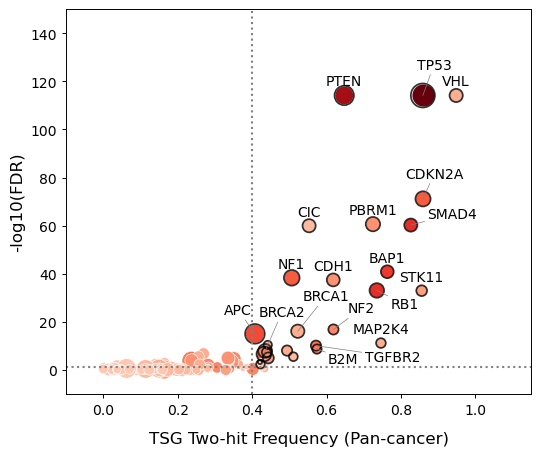

In [23]:
config_rcparams()

genes_to_annotate = {
    "SMAD4":(30,-2),
    "RB1":(20,-20),
    "TGFBR2":(55,-18),
    "B2M":(19,-17),
    "NF2":(20,5),
    "BRCA1":(20,15),
    "MEN1":(5,8),
    "APC":(-12,7),
    "TP53":(8,12),
    "CDKN2A":(8,8),
    "BRCA2":(13,20),
}
'''
    "AJUBA":(50,50),
    "BRD7":(50,50),
    "TSC1":(50,50),
    "CDKN2C":(50,50),
    "RASA":(50,50),
    "SETD2":(50,50),
}'''

fig, ax = plt.subplots(figsize=(6,5))

lower_hue = -5
upper_hue = 19
norm = mcolors.Normalize(vmin=lower_hue, vmax=upper_hue)

sns.scatterplot(data=data_pancan_mod[data_pancan_mod.tot>2000],x='2hitfreq',y='-log(FDR)', hue='tumors', palette='Reds', hue_norm=norm, alpha=1, ax=ax, s=300, legend=False)
sns.scatterplot(data=data_pancan_mod[data_pancan_mod.tot<2000],x='2hitfreq',y='-log(FDR)', hue='tumors', palette='Reds', hue_norm=norm, alpha=1, ax=ax, size='bubble_size', sizes=(10,200), legend=False)

th = (-np.log10(0.05))

sel=data_pancan_mod[(data_pancan_mod['2hitfreq']>0.4)&(data_pancan_mod['-log(FDR)']>th)]
sns.scatterplot(data=sel[sel.tot>2000],x='2hitfreq',y='-log(FDR)', color='None', alpha=0.8, ax=ax, edgecolor='k',linewidth=1.25, s=300)
sns.scatterplot(data=sel[sel.tot<2000],x='2hitfreq',y='-log(FDR)', color='None', alpha=0.8, ax=ax, edgecolor='k',linewidth=1.25, size='bubble_size', sizes=(10,200), legend=False)


plt.axvline(x=0.4, linestyle=':',color='grey')
plt.axhline(y=th, linestyle=':',color='grey')

sel=data_pancan_mod[(data_pancan_mod['2hitfreq']>0.4)&(data_pancan_mod['-log(FDR)']>12)|(data_pancan_mod['2hitfreq']>0.55)|(data_pancan_mod['Hugo_Symbol']=='BRCA2')]

for _, row in sel.iterrows():
    x, y = row['2hitfreq'], row['-log(FDR)']
    label = row['Hugo_Symbol']
    dx, dy = (0, 5)  
    
    if label in genes_to_annotate:
        extra_dx, extra_dy = genes_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=10,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=10,
            ha="center", va="bottom",          
        )

plt.xlim(-0.1,1.15)
plt.ylim(-10,150)
plt.xlabel('TSG Two-hit Frequency (Pan-cancer)', fontsize=12, labelpad=10)
plt.ylabel('-log10(FDR)', fontsize=12)

plt.show()

---